# Validation and Comparison

This notebook loads pre-computed validation metrics and creates visualizations.

**Prerequisites:** Run `python3 run_validation.py` first to generate metrics.

**What this notebook does:**
1. Loads validation metrics from CSV
2. Displays performance summary with KL divergence, KS similarity, correlation
3. Creates visualizations (ranking charts, dashboards)

In [11]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.validation.metrics import ValidationMetrics
from src.visualization.comparison_plots import ComparisonVisualizer

import warnings
warnings.filterwarnings('ignore')

sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Validation Metrics

The validation has already been run by `run_validation.py`. This notebook loads the results and creates visualizations.

In [12]:
# Load validation metrics from the validation script
validation_dir = Path.cwd().parent / 'data/validation'
metrics_file = validation_dir / 'validation_metrics.csv'

if not metrics_file.exists():
    print("\n⚠️  No validation metrics found!")
    print("   Run: python3 run_validation.py")
    print("   This will generate and compare synthetic data against ground truth.")
else:
    print(f"Loading validation metrics: {metrics_file.name}")
    df_metrics = pd.read_csv(metrics_file)
    print(f"✓ Loaded metrics for {len(df_metrics)} questions")
    
    print("\nAvailable metrics:")
    print(df_metrics.columns.tolist())
    
    print("\nMetrics preview:")
    print(df_metrics.head())

Loading validation metrics: validation_metrics.csv
✓ Loaded metrics for 7 questions

Available metrics:
['kl_divergence', 'js_divergence', 'chi2_statistic', 'chi2_p_value', 'ks_statistic', 'ks_p_value', 'ground_truth_mean', 'synthetic_mean', 'mean_difference', 'mean_absolute_error', 'ground_truth_std', 'synthetic_std', 'question', 'gt_n', 'syn_n']

Metrics preview:
   kl_divergence  js_divergence  chi2_statistic   chi2_p_value  ks_statistic  \
0       0.501484       0.132388     2561.293347   0.000000e+00      0.476944   
1       0.727200       0.157601     2125.976163   0.000000e+00      0.469722   
2       0.592532       0.093892      746.501311  4.319254e-159      0.333611   
3       0.034558       0.008762       90.767509   9.045900e-19      0.101111   
4       0.314689       0.080091     1161.046159  4.431970e-250      0.345000   

     ks_p_value  ground_truth_mean  synthetic_mean  mean_difference  \
0  8.518350e-40           3.027500        2.320000        -0.707500   
1  1.4856

## 2. Overall Performance Summary

In [13]:
# Calculate overall performance
print("Overall Performance:")
print("="*80)

# Mean KL divergence (lower is better, 0 = perfect match)
mean_kl = df_metrics['kl_divergence'].mean()
print(f"\nMean KL Divergence: {mean_kl:.4f}")
print(f"  Interpretation:")
print(f"    < 0.05 = Excellent ⭐")
print(f"    0.05-0.10 = Good ✓")
print(f"    0.10-0.20 = Acceptable")
print(f"    > 0.20 = Needs improvement")

# Mean KS statistic
mean_ks = df_metrics['ks_statistic'].mean()
print(f"\nMean KS Statistic: {mean_ks:.4f}")
print(f"  (Lower is better, 0 = identical)")

# Mean KS similarity (paper's metric)
if 'ks_similarity' in df_metrics.columns:
    mean_ks_sim = df_metrics['ks_similarity'].mean()
    print(f"\nMean KS Similarity: {mean_ks_sim:.4f}")
    print(f"  Interpretation:")
    print(f"    > 0.85 = Good (paper benchmark)")
    print(f"    Paper results: GPT-4o SSR = 0.88, Gemini-2f SSR = 0.80")

# Mean absolute error on means
mean_mae = df_metrics['mean_absolute_error'].mean()
print(f"\nMean Absolute Error (on means): {mean_mae:.4f}")

# Correlation on means
if len(df_metrics) > 2:
    from src.validation.metrics import ValidationMetrics
    corr = ValidationMetrics.correlation(
        df_metrics['ground_truth_mean'].values,
        df_metrics['synthetic_mean'].values
    )
    print(f"\nCorrelation (on means): {corr:.4f}")
    
    # Correlation attainment (target >85%)
    corr_att = ValidationMetrics.correlation_attainment(corr, 0, reliability=0.85)
    print(f"Correlation Attainment: {corr_att:.1f}%")
    print(f"  Target: >85% (human test-retest reliability)")
    print(f"  Paper Benchmark: ~90%")

# Distribution of KL divergence
print(f"\nKL Divergence Distribution:")
print(f"  Min: {df_metrics['kl_divergence'].min():.4f}")
print(f"  25th percentile: {df_metrics['kl_divergence'].quantile(0.25):.4f}")
print(f"  Median: {df_metrics['kl_divergence'].median():.4f}")
print(f"  75th percentile: {df_metrics['kl_divergence'].quantile(0.75):.4f}")
print(f"  Max: {df_metrics['kl_divergence'].max():.4f}")

# Show top and bottom performers
print(f"\n✅ Best Performing Questions (Lowest KL):")
best_5 = df_metrics.nsmallest(5, 'kl_divergence')
for idx, row in best_5.iterrows():
    print(f"  {row['question']:12s} - KL: {row['kl_divergence']:.4f}  (GT mean: {row['ground_truth_mean']:.2f}, Syn mean: {row['synthetic_mean']:.2f})")

print(f"\n⚠️  Questions Needing Improvement (Highest KL):")
worst_3 = df_metrics.nlargest(3, 'kl_divergence')
for idx, row in worst_3.iterrows():
    print(f"  {row['question']:12s} - KL: {row['kl_divergence']:.4f}  (GT mean: {row['ground_truth_mean']:.2f}, Syn mean: {row['synthetic_mean']:.2f})")

Overall Performance:

Mean KL Divergence: 0.4713
  Interpretation:
    < 0.05 = Excellent ⭐
    0.05-0.10 = Good ✓
    0.10-0.20 = Acceptable
    > 0.20 = Needs improvement

Mean KS Statistic: 0.3520
  (Lower is better, 0 = identical)

Mean Absolute Error (on means): 0.7898

Correlation (on means): 0.1253
Correlation Attainment: 14.7%
  Target: >85% (human test-retest reliability)
  Paper Benchmark: ~90%

KL Divergence Distribution:
  Min: 0.0346
  25th percentile: 0.2873
  Median: 0.5015
  75th percentile: 0.6599
  Max: 0.8689

✅ Best Performing Questions (Lowest KL):
  PRPURINT     - KL: 0.0346  (GT mean: 3.21, Syn mean: 3.08)
  RELVANCE     - KL: 0.2599  (GT mean: 2.44, Syn mean: 3.29)
  PRVALMNY     - KL: 0.3147  (GT mean: 3.54, Syn mean: 2.76)
  BELVBLTY     - KL: 0.5015  (GT mean: 3.03, Syn mean: 2.32)
  LIKBILTY     - KL: 0.5925  (GT mean: 3.71, Syn mean: 2.78)

⚠️  Questions Needing Improvement (Highest KL):
  UNIQNESS     - KL: 0.8689  (GT mean: 3.64, Syn mean: 2.45)
  EXCITME

## 3. Visualizations

Create comparison visualizations from the metrics data.

Creating metric dashboard...


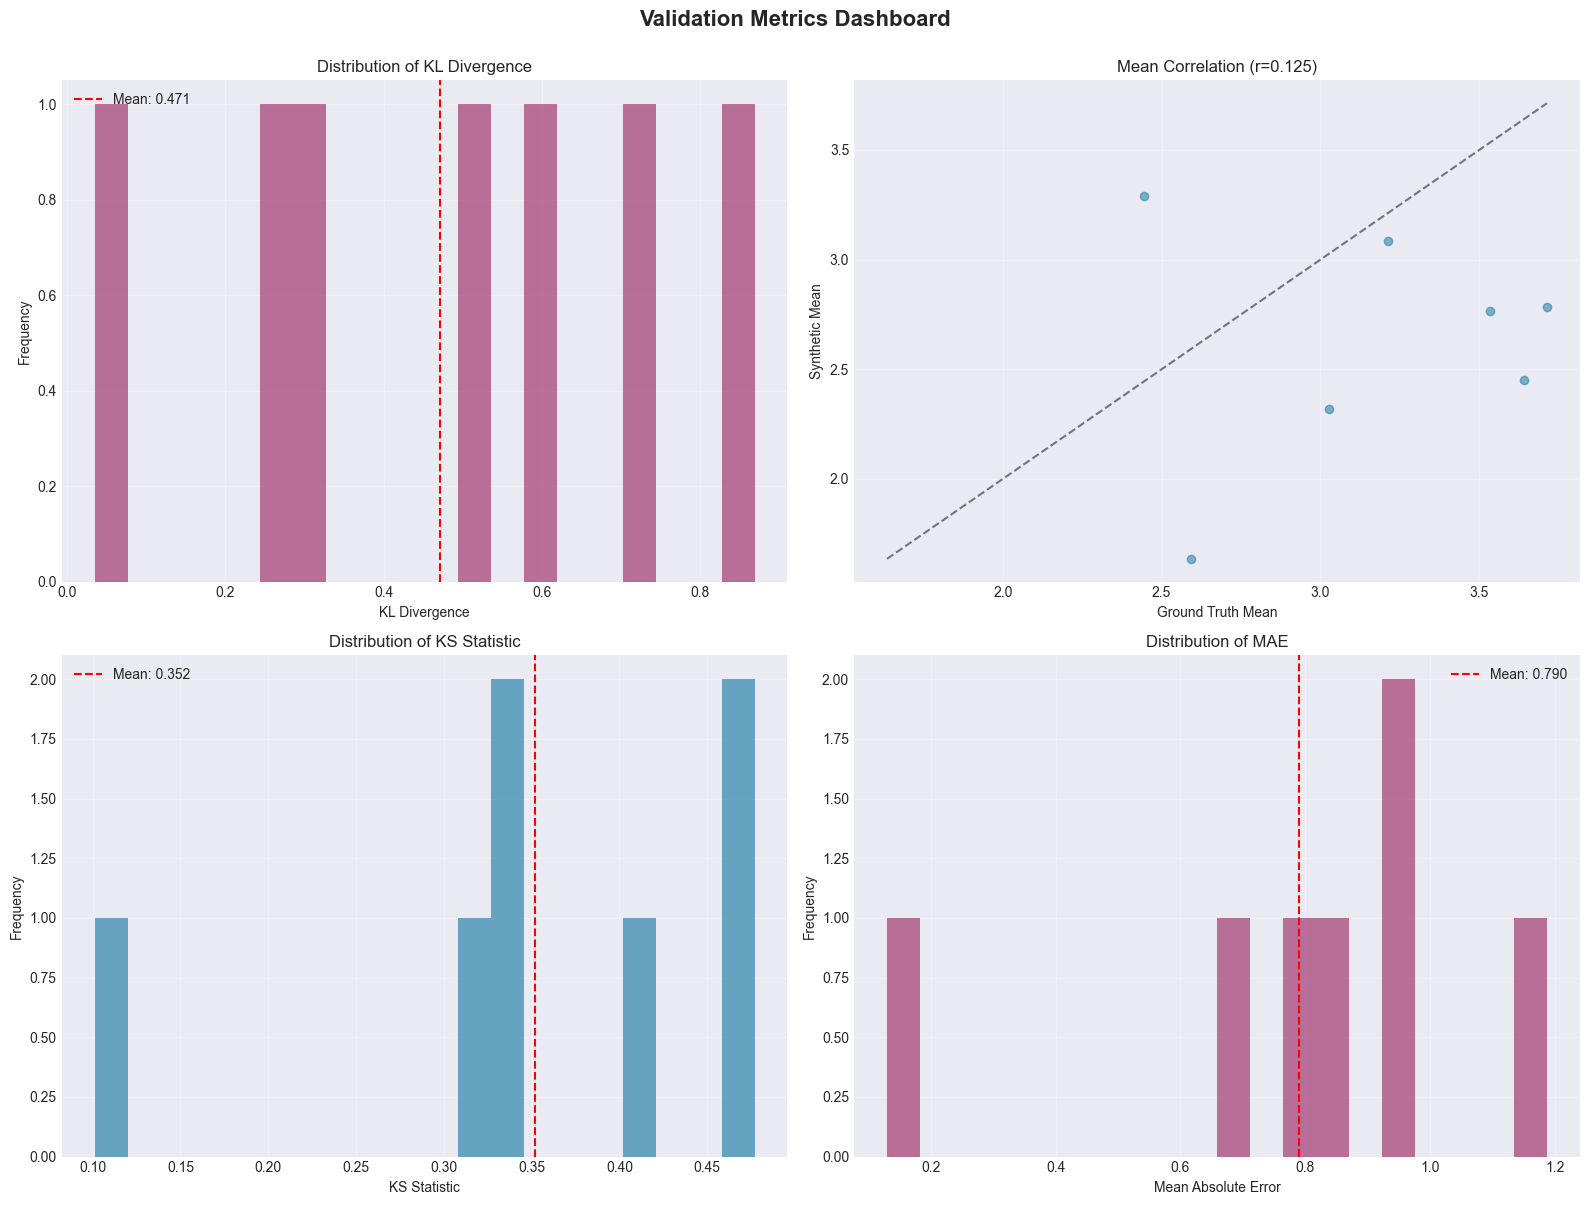

✓ Saved: metric_dashboard.png

Creating mean score comparison...


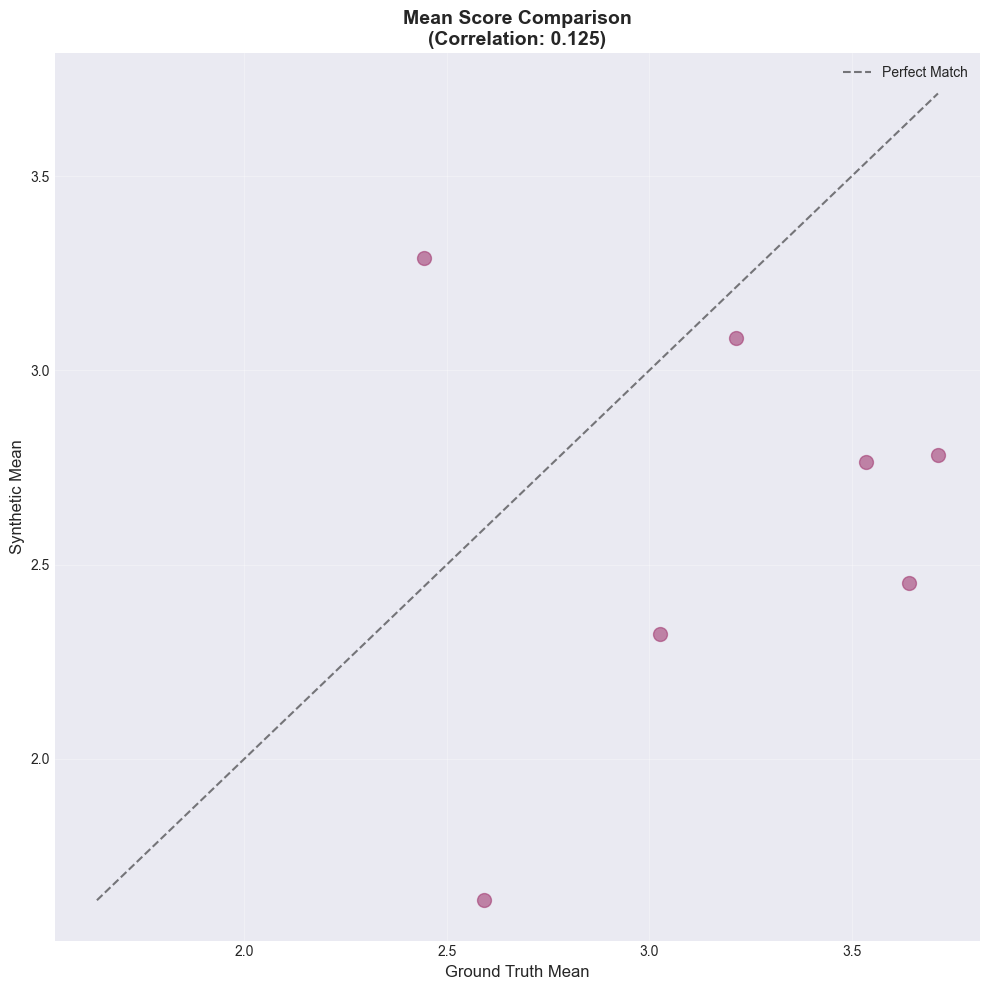

✓ Saved: mean_scatter.png

Creating KL divergence ranking chart...


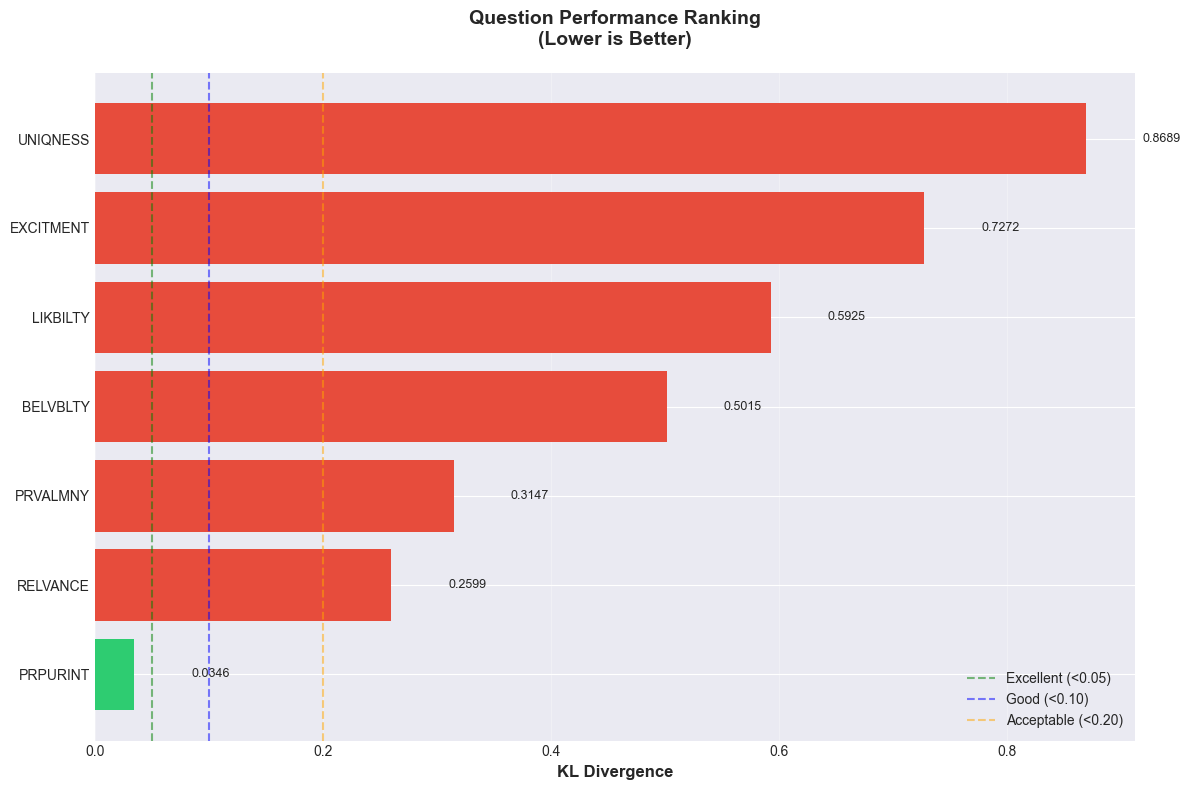

✓ Saved: kl_ranking.png

✅ All visualizations saved to: /Users/mark.stent/Projects/python/kantar-test/data/validation


In [14]:
# Initialize visualizer
visualizer = ComparisonVisualizer()

# Output directory
output_dir = Path.cwd().parent / 'data/validation'
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Metric Dashboard
print("Creating metric dashboard...")
try:
    fig = visualizer.plot_metric_dashboard(df_metrics, figsize=(16, 12))
    plt.show()
    fig.savefig(output_dir / 'metric_dashboard.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: metric_dashboard.png")
except Exception as e:
    print(f"⚠️  Could not create metric dashboard: {e}")

# 2. Mean Score Scatter Plot
print("\nCreating mean score comparison...")
try:
    fig = visualizer.plot_mean_scatter(df_metrics, figsize=(10, 10))
    plt.show()
    fig.savefig(output_dir / 'mean_scatter.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: mean_scatter.png")
except Exception as e:
    print(f"⚠️  Could not create mean scatter: {e}")

# 3. KL Divergence Ranking
print("\nCreating KL divergence ranking chart...")
fig, ax = plt.subplots(figsize=(12, 8))

df_sorted = df_metrics.sort_values('kl_divergence')

# Color coding based on performance
colors = []
for kl in df_sorted['kl_divergence']:
    if kl < 0.05:
        colors.append('#2ecc71')  # Excellent - green
    elif kl < 0.10:
        colors.append('#3498db')  # Good - blue
    elif kl < 0.20:
        colors.append('#f39c12')  # Acceptable - orange
    else:
        colors.append('#e74c3c')  # Needs improvement - red

bars = ax.barh(range(len(df_sorted)), df_sorted['kl_divergence'], color=colors)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['question'])
ax.set_xlabel('KL Divergence', fontsize=12, fontweight='bold')
ax.set_title('Question Performance Ranking\n(Lower is Better)', fontsize=14, fontweight='bold', pad=20)

# Reference lines
ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.5, label='Excellent (<0.05)')
ax.axvline(x=0.10, color='blue', linestyle='--', alpha=0.5, label='Good (<0.10)')
ax.axvline(x=0.20, color='orange', linestyle='--', alpha=0.5, label='Acceptable (<0.20)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Value labels
for i, (bar, val) in enumerate(zip(bars, df_sorted['kl_divergence'])):
    ax.text(val + 0.05, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
fig.savefig(output_dir / 'kl_ranking.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: kl_ranking.png")

print(f"\n✅ All visualizations saved to: {output_dir}")

## Summary

✅ **Validation Report Created**

This notebook loads pre-computed validation metrics from `run_validation.py` and creates comprehensive visualizations.

**Workflow:**
1. Run `python3 run_validation.py` to generate metrics
2. Run this notebook to visualize results

**Key Metrics:**
- **KL Divergence**: Distribution similarity (lower = better, <0.05 = excellent)
- **KS Similarity**: Paper's metric (higher = better, >0.85 = good)
- **Correlation**: Mean score match
- **Correlation Attainment**: % of human test-retest reliability (target: >85%)

**Outputs Saved:**
- `validation_metrics.csv` - Detailed metrics per question
- `validation_report.txt` - Text summary report
- `metric_dashboard.png` - Overview dashboard (if ComparisonVisualizer available)
- `mean_scatter.png` - Mean score comparison (if ComparisonVisualizer available)
- `kl_ranking.png` - Question performance ranking

**Next Steps:**
- Review metrics to identify strong/weak questions
- Adjust anchor statements for high KL divergence questions
- Refine persona generation if needed
- Re-run validation after improvements